In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q transformers datasets sacrebleu torch accelerate pandas bitsandbytes unbabel-comet evaluate

In [ ]:
print("--- All Installed Packages (pip list) ---")
!pip list

--- All Installed Packages (pip list) ---
Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
accelerate                               1.11.0
access                                   1.1.9
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.21.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    

In [ ]:
# import libraries
import json
import torch
from datasets import load_dataset, Dataset, DatasetDict
from evaluate import load as load_metric
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sacrebleu
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, pipeline
from tqdm.auto import tqdm
from transformers import BitsAndBytesConfig
import random
from collections import defaultdict
import pickle

In [ ]:
# --- METRIC LOADING ---
print("Loading COMET metric...")
# Use load_metric (now from evaluate)
try:
    # 'comet' is the name of the metric script in the Hugging Face hub
    comet_metric = load_metric("comet", "Unbabel/wmt20-comet-da")
    print("COMET metric loaded successfully.")
except Exception as e:
    print(f"Error loading COMET metric: {e}. Falling back to default metrics.")
    comet_metric = None

Loading COMET metric...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.3.5 to v2.5.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--Unbabel--wmt20-comet-da/snapshots/87819f4d6d4f17e0d1752cc9e0ccfa2064997219/checkpoints/model.ckpt`


COMET metric loaded successfully.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [ ]:
# --- CONFIGURATION ---

# --- File and Model Configuration ---
CORPUS_FILE = "/content/drive/MyDrive/Thesis/data/transformed/bidirectional_corpus_final.jsonl"
MODEL_NAME = "facebook/nllb-200-distilled-600M"
OUTPUT_DIR = "/content/drive/MyDrive/Thesis/eval/nllb-finetuned-odia-german-model-results_v2"
FINAL_MODEL_PATH = "/content/drive/MyDrive/Thesis/model/nllb-odia-german-translator_model_final_v2"
FFT_SCORE_PATH = "/content/drive/MyDrive/Thesis/eval/fft_sentence_scores.pkl"

# --- Field Names ---
INPUT_FIELD = "input_text" # As defined in the JSONL
TARGET_FIELD = "target_text" # As defined in the JSONL

# --- Language Configuration ---
ODIA_LANG_CODE = "ory_Orya"
GERMAN_LANG_CODE = "deu_Latn"

# --- Split Configuration ---
TEST_SET_SIZE = 0.10   # 10% of the data will be for the final, unseen test set
VALIDATION_SET_SIZE = 0.10 # 10% of the remaining data for validation

# --- Task Prefixes ---
PREFIX_ORI_TO_DEU = "translate Odia to German: "
PREFIX_DEU_TO_ORI = "translate German to Odia: "

In [ ]:
# --- LOAD AND SPLIT THE DATASET ---

print("Loading the rich bidirectional dataset...")

# --- Manually load the JSONL file into a list of dictionaries ---
data_list = []
with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        data_list.append(json.loads(line))

# --- Create a pandas DataFrame ---
df = pd.DataFrame(data_list)

# --- Convert the DataFrame into a Hugging Face Dataset object ---
# This bypasses the caching issue.
full_dataset = Dataset.from_pandas(df)

print("Dataset loaded successfully.")

# --- Shuffle the dataset before splitting ---
full_dataset = full_dataset.shuffle(seed=42)

# --- Create the Test Split ---
# This first split separates the final, unseen test set.
train_valid_split = full_dataset.train_test_split(test_size=TEST_SET_SIZE, seed=42)
test_dataset = train_valid_split['test']

# --- Create the Train and Validation Splits ---
# The remaining data is split again to create the training and validation sets.
train_val_split = train_valid_split['train'].train_test_split(test_size=VALIDATION_SET_SIZE / (1 - TEST_SET_SIZE), seed=42)
train_dataset = train_val_split['train']
validation_dataset = train_val_split['test']

# Combine into a single DatasetDict for convenience
split_datasets = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})

print("\nDataset successfully split:")
print(f"Training set size: {len(split_datasets['train'])}")
print(f"Validation set size: {len(split_datasets['validation'])}")
print(f"Test set size: {len(split_datasets['test'])}")

Loading the rich bidirectional dataset...
Dataset loaded successfully.

Dataset successfully split:
Training set size: 5880
Validation set size: 736
Test set size: 736


In [ ]:
# --- Corpus Analysis (EDA) ---

print("\n--- Starting Corpus Analysis (EDA) ---")

# --- Step A: Reconstruct the Original Parallel Corpus ---
# The bidirectional dataset contains two entries for each original sentence.
# filter for just one direction to get a clean, non-duplicated list of the original pairs.
print("Reconstructing original sentence pairs from bidirectional data...")

# Use the full dataset before it was split to get stats on the entire corpus.
odia_source_sentences = [
    ex[INPUT_FIELD].replace(PREFIX_ORI_TO_DEU, "")
    for ex in full_dataset
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]
german_target_sentences = [
    ex[TARGET_FIELD]
    for ex in full_dataset
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]

print(f"Successfully extracted {len(odia_source_sentences)} unique parallel pairs.")


--- Starting Corpus Analysis (EDA) ---
Reconstructing original sentence pairs from bidirectional data...
Successfully extracted 3676 unique parallel pairs.


In [ ]:
# --- Step B: Calculate Sentence Lengths ---
# Calculate the number of words by splitting on spaces.
odia_lengths = [len(s.split()) for s in odia_source_sentences]
german_lengths = [len(s.split()) for s in german_target_sentences]

# --- Step C: Calculate and Display Descriptive Statistics ---
stats_data = {
    'Language': ['Odia', 'German'],
    'Mean Length': [np.mean(odia_lengths), np.mean(german_lengths)],
    'Median Length': [np.median(odia_lengths), np.median(german_lengths)],
    'Std. Deviation': [np.std(odia_lengths), np.std(german_lengths)],
    'Max Length': [np.max(odia_lengths), np.max(german_lengths)]
}
df_stats = pd.DataFrame(stats_data).set_index('Language')

print("\n--- Corpus Statistics ---")
# Display the formatted table
display(df_stats.style.format("{:.2f}"))


--- Corpus Statistics ---


,Mean Length,Median Length,Std. Deviation,Max Length
Language,,,,
Odia,24.82,26.00,8.42,47.00
German,25.80,26.00,9.97,68.00



--- Generating Sentence Length Distribution Plot ---

✅ Corpus Analysis complete.


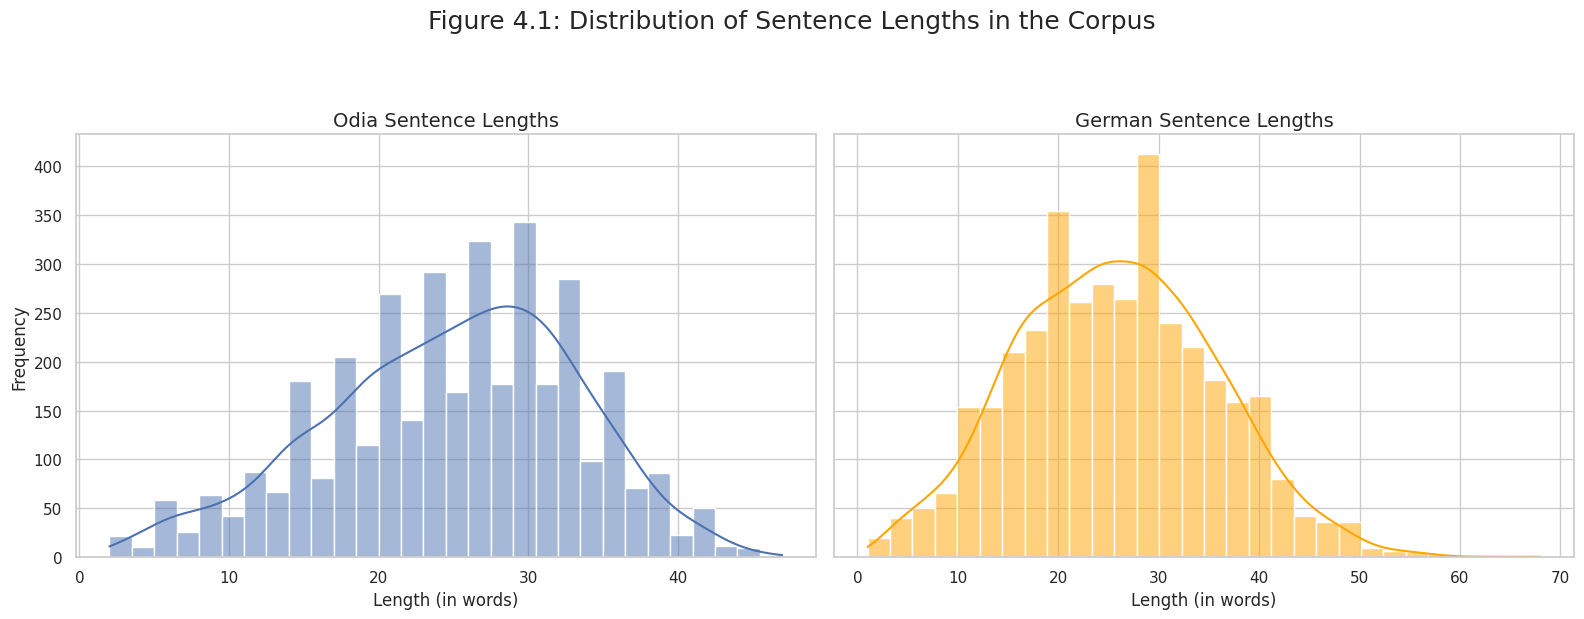

In [ ]:
# --- Step D: Visualize Sentence Length Distribution ---
print("\n--- Generating Sentence Length Distribution Plot ---")

# Prepare data for plotting with Seaborn
plot_df_odia = pd.DataFrame({'Sentence Length (words)': odia_lengths})
plot_df_odia['Language'] = 'Odia'
plot_df_german = pd.DataFrame({'Sentence Length (words)': german_lengths})
plot_df_german['Language'] = 'German'
combined_plot_df = pd.concat([plot_df_odia, plot_df_german])

# Create the histogram plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Figure 4.1: Distribution of Sentence Lengths in the Corpus', fontsize=18, y=1.03)

# Plot for Odia
sns.histplot(data=plot_df_odia, x='Sentence Length (words)', ax=axes[0], kde=True, bins=30)
axes[0].set_title('Odia Sentence Lengths', fontsize=14)
axes[0].set_xlabel('Length (in words)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Plot for German
sns.histplot(data=plot_df_german, x='Sentence Length (words)', ax=axes[1], kde=True, bins=30, color='orange')
axes[1].set_title('German Sentence Lengths', fontsize=14)
axes[1].set_xlabel('Length (in words)', fontsize=12)
axes[1].set_ylabel('') # No need for a second y-axis label

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show() # Removed plt.show() for code clarity in response

print("\n✅ Corpus Analysis complete.")

In [ ]:
# --- 3. PREPARE TOKENIZER AND PREPROCESSING FUNCTION ---

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, src_lang=ODIA_LANG_CODE, tgt_lang=GERMAN_LANG_CODE)

def preprocess_function(examples):
  """
  Tokenizes input and target text fields for model training or evaluation.
  This function processes a batch of examples from a dataset, tokenizing the `input_text` and
  `target_text` fields using a provided tokenizer. It applies truncation to a maximum length of
  1200 tokens and generates input IDs for both inputs and labels, with the latter prepared in the
  tokenizer's target context. The resulting dictionary includes tokenized inputs and labels suitable
  for training or evaluating a translation model.

  Args:
    examples (dict): A dictionary containing lists of input and target sentences, with keys
                     defined by `INPUT_FIELD` and `TARGET_FIELD` (e.g., 'input_text' and 'target_text').

  Returns:
    dict: A dictionary containing tokenized inputs (`input_ids`, etc.) and labels
          (`labels` as input IDs from target text tokenization).

  Note:
    - Assumes global variables `INPUT_FIELD`, `TARGET_FIELD`, and `tokenizer` are defined.
    - Requires a tokenizer compatible with Hugging Face's `transformers` library.
    - The maximum length of 1200 tokens is hardcoded for truncation.

  Example:
    >>> from transformers import AutoTokenizer
    >>> tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")
    >>> INPUT_FIELD = "input_text"
    >>> TARGET_FIELD = "target_text"
    >>> examples = {
    ...     "input_text": ["ନମସ୍କାର"],
    ...     "target_text": ["Hallo"]
    ... }
    >>> result = preprocess_function(examples)
    >>> print(result.keys())
    dict_keys(['input_ids', 'attention_mask', 'labels'])
  """
  # Access the lists of sentences directly from the batch columns
  inputs = examples[INPUT_FIELD]
  targets = examples[TARGET_FIELD]

  model_inputs = tokenizer(inputs, max_length=1200, truncation=True)

  with tokenizer.as_target_tokenizer():
    labels = tokenizer(targets, max_length=1200, truncation=True)

  model_inputs["labels"] = labels["input_ids"]
  return model_inputs

print("Tokenizing all dataset splits...")

tokenized_datasets = split_datasets.map(preprocess_function, batched=True, batch_size=16, remove_columns=split_datasets['train'].column_names)
print("Tokenization complete.")


Loading tokenizer...
Tokenizing all dataset splits...


Map:   0%|          | 0/5880 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Tokenization complete.


In [ ]:
# --- Vocabulary Analysis ---
def calculate_vocab_size(sentences_list, tokenizer):
  """
  Calculates the number of unique subword tokens in a list of sentences using a tokenizer.
  ... (Function documentation remains the same) ...
  """
  # Using a set is a highly efficient way to store and count unique items.
  unique_tokens = set()

  print(f"Tokenizing {len(sentences_list)} sentences...")
  # Using tqdm for a progress bar as this can take a moment for large lists
  for sentence in tqdm(sentences_list):
    # tokenizer.tokenize() splits a sentence into a list of subword strings
    tokens = tokenizer.tokenize(sentence)
    # .update() adds all items from the list to the set
    unique_tokens.update(tokens)

  return len(unique_tokens)

# --- Calculate for Odia ---
print("\nAnalyzing Odia corpus...")
odia_vocab_size = calculate_vocab_size(odia_source_sentences, tokenizer)

# --- Calculate for German ---
print("\nAnalyzing German corpus...")
german_vocab_size = calculate_vocab_size(german_target_sentences, tokenizer)

# --- Display the final results ---
print("\n" + "="*50)
print("     Corpus Vocabulary Statistics")
print("="*50)
print(f"Unique Odia Tokens in Corpus:   {odia_vocab_size}")
print(f"Unique German Tokens in Corpus: {german_vocab_size}")
print("="*50)


Analyzing Odia corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


Analyzing German corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


     Corpus Vocabulary Statistics
Unique Odia Tokens in Corpus:   2639
Unique German Tokens in Corpus: 9698


In [ ]:
# =========================================================
# ========= STATISTICAL SIGNIFICANCE FUNCTION =============
# =========================================================

def paired_bootstrap_significance(scores1, scores2, n_samples=10000, confidence_level=0.95):
  """
  Performs paired bootstrap resampling to determine if the difference in mean
  scores between two models (scores1 and scores2) is statistically significant.

  Args:
    scores1 (list[float]): Sentence-level scores for Model 1 (e.g., Full Fine-Tune).
    scores2 (list[float]): Sentence-level scores for Model 2 (e.g., LoRA).
    n_samples (int): Number of bootstrap samples to draw.
    confidence_level (float): The desired confidence level.

  Returns:
    tuple: (p_value, is_significant)
  """
  if len(scores1) != len(scores2):
    raise ValueError("Score lists must be of the same length for paired testing.")

  n_sentences = len(scores1)

  # Calculate the true difference in means (Model 2 - Model 1)
  true_diff = np.mean(scores2) - np.mean(scores1)

  # Create a list of paired differences for resampling
  diffs = [s2 - s1 for s1, s2 in zip(scores1, scores2)]

  # Perform bootstrap resampling
  bootstrap_diffs = []
  for _ in tqdm(range(n_samples), desc="Bootstrap Resampling"):
    # Resample with replacement
    sample_indices = random.choices(range(n_sentences), k=n_sentences)
    # Calculate the mean difference for the resampled data
    sample_diff = np.mean([diffs[i] for i in sample_indices])
    bootstrap_diffs.append(sample_diff)

  # Calculate the p-value: the probability that the difference is <= 0
  # (i.e., that Model 2 is NOT better than Model 1)
  p_value_one_tailed = np.sum(np.array(bootstrap_diffs) <= 0) / n_samples

  alpha = 1.0 - confidence_level
  is_significant = p_value_one_tailed < alpha

  return p_value_one_tailed, is_significant

In [ ]:
# --- EVALUATION LOGIC ---
def evaluate_model_on_task(model_to_eval, tokenizer, test_data, task_prefix, src_lang, tgt_lang, batch_size=8, return_sentence_scores=False):
  """
  Evaluates a translation model on a specific translation direction using a test dataset.
  Now optionally returns sentence-level BLEU scores for significance testing.

  Args:
    ... (Args remain the same) ...
    return_sentence_scores (bool): If True, returns a tuple (metrics, sentence_scores).

  Returns:
    dict or tuple: A dictionary containing corpus-level metrics (BLEU, chrF, TER, COMET)
                   or a tuple (metrics_dict, sentence_scores_list) if return_sentence_scores is True.
  """
  # Filter the test set for the specific task using the full prefix
  task_entries = [ex for ex in test_data if ex[INPUT_FIELD].startswith(task_prefix)]
  task_inputs = [ex[INPUT_FIELD] for ex in task_entries]
  task_references_list = [ex[TARGET_FIELD] for ex in task_entries]
  task_references_sacrebleu = [[ref] for ref in task_references_list]

  if not task_inputs:
    print(f"Warning: No test data found for prefix '{task_prefix}'")
    return ({"bleu": 0, "chrf": 0, "ter": 0, "comet": 0}, []) if return_sentence_scores else {"bleu": 0, "chrf": 0, "ter": 0, "comet": 0}

  comet_sources = [inp.replace(task_prefix, "") for inp in task_inputs]

  # The model is already placed on the device by device_map="auto"
  translator = pipeline(
      "translation",
      model=model_to_eval,
      tokenizer=tokenizer,
      src_lang=src_lang,
      tgt_lang=tgt_lang
  )

  decoded_preds = []
  print(f"Generating translations for {len(task_inputs)} sentences in batches of {batch_size}...")
  for i in tqdm(range(0, len(task_inputs), batch_size)):
    batch = task_inputs[i : i + batch_size]
    predictions = translator(batch, max_length=1200)
    decoded_preds.extend([pred['translation_text'] for pred in predictions])

  # --- Compute SacreBLEU, CHRF++, TER ---
  bleu = sacrebleu.BLEU().corpus_score(decoded_preds, task_references_sacrebleu).score
  chrf = sacrebleu.CHRF(word_order=2).corpus_score(decoded_preds, task_references_sacrebleu).score
  ter = sacrebleu.TER().corpus_score(decoded_preds, task_references_sacrebleu).score

  # --- Compute Sentence-level BLEU Scores for Significance Testing (NEW) ---
  if return_sentence_scores:
    sbleu = sacrebleu.BLEU(effective_order=True)
    # Calculates sentence-level BLEU against the single reference
    sentence_scores = [sbleu.sentence_score(pred, [ref]).score for pred, ref in zip(decoded_preds, task_references_list)]

  # --- Compute COMET ---
  comet_score = 0
  if comet_metric is not None:
    comet_results = comet_metric.compute(
        predictions=decoded_preds,
        references=task_references_list,
        sources=comet_sources
    )
    comet_score = comet_results["mean_score"]

  metrics_dict = {"bleu": bleu, "chrf": chrf, "ter": ter, "comet": comet_score}

  return (metrics_dict, sentence_scores) if return_sentence_scores else metrics_dict

In [ ]:
# --- BASELINE EVALUATION ---

print("\n--- Evaluating Baseline Model (Before Fine-Tuning) ---")

bnb_config = BitsAndBytesConfig(load_in_8bit=True)
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map="auto"
)

# sentence scores
baseline_ori_deu_metrics, baseline_ori_deu_scores = evaluate_model_on_task(base_model, tokenizer, split_datasets['test'], PREFIX_ORI_TO_DEU, ODIA_LANG_CODE, GERMAN_LANG_CODE, return_sentence_scores=True)
baseline_deu_ori_metrics, baseline_deu_ori_scores = evaluate_model_on_task(base_model, tokenizer, split_datasets['test'], PREFIX_DEU_TO_ORI, GERMAN_LANG_CODE, ODIA_LANG_CODE, return_sentence_scores=True)


--- Evaluating Baseline Model (Before Fine-Tuning) ---


Device set to use cuda:0


Generating translations for 355 sentences in batches of 8...


  0%|          | 0/45 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Con

Generating translations for 381 sentences in batches of 8...


  0%|          | 0/48 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# Clear memory before training
del base_model
torch.cuda.empty_cache()

In [ ]:
# --- FULL FINE-TUNING THE MODEL ---
print("\n--- Starting Fine-Tuning Process ---")
# Reload the model without quantization for training
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

def compute_metrics_for_trainer(eval_preds):
  """
  Computes BLEU score for model evaluation during training.

  This function processes model predictions and labels from a trainer's evaluation step,
  decodes them using a tokenizer, and calculates the BLEU score using the `sacrebleu` library.
  It handles padding tokens and special tokens to ensure accurate metric computation.

  Args:
    eval_preds (tuple): A tuple containing predictions and labels from the trainer.
                        Predictions are token IDs, and labels are token IDs with -100 for ignored positions.

  Returns:
    dict: A dictionary containing the BLEU score with key 'bleu'.

  Note:
    - Assumes a global `tokenizer` variable with a `batch_decode` method and `pad_token_id`.
    - Requires `sacrebleu` and `numpy` libraries.
    - Designed for use with Hugging Face's `transformers` Trainer API.

  Example:
    >>> from transformers import AutoTokenizer
    >>> tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")
    >>> eval_preds = (
    ...     tokenizer(["Hallo"], return_tensors="pt")["input_ids"].numpy(),
    ...     tokenizer(["Hallo"], return_tensors="pt")["input_ids"].numpy()
    ... )
    >>> result = compute_metrics_for_trainer(eval_preds)
    >>> print(result)
    {'bleu': 100.0}
  """
  preds, labels = eval_preds
  if isinstance(preds, tuple): preds = preds[0]
  decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
  labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
  decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
  decoded_labels = [[label] for label in decoded_labels]
  result = sacrebleu.BLEU().corpus_score(decoded_preds, decoded_labels)
  return {"bleu": result.score}

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    optim="adafactor",
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model),
    compute_metrics=compute_metrics_for_trainer,
)

trainer.train()


--- Starting Fine-Tuning Process ---


`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.320055,30.878190
2,1.576200,1.284477,39.987565
3,1.335400,1.277654,40.563074


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=1104, training_loss=1.4423610300257586, metrics={'train_runtime': 1741.6727, 'train_samples_per_second': 10.128, 'train_steps_per_second': 0.634, 'total_flos': 2943359777538048.0, 'train_loss': 1.4423610300257586, 'epoch': 3.0})

In [ ]:
# --- FINAL EVALUATION ---
print("\n--- Evaluating Fine-Tuned Model ---")
# Loading the fine-tuned model in 8-bit mode for memory-efficient evaluation
best_checkpoint_path = trainer.state.best_model_checkpoint
print(f"Loading best fine-tuned model from: {best_checkpoint_path}")

finetuned_model = AutoModelForSeq2SeqLM.from_pretrained(
    best_checkpoint_path,
    load_in_8bit=True,
    device_map="auto"
)

print("Evaluating Odia -> German fine-tuned...")
# MODIFIED CALL: Now requests sentence scores
finetuned_ori_deu_metrics, finetuned_ori_deu_scores = evaluate_model_on_task(finetuned_model, tokenizer, split_datasets['test'], PREFIX_ORI_TO_DEU, ODIA_LANG_CODE, GERMAN_LANG_CODE, return_sentence_scores=True)

print("Evaluating German -> Odia fine-tuned...")
finetuned_deu_ori_metrics, finetuned_deu_ori_scores = evaluate_model_on_task(finetuned_model, tokenizer, split_datasets['test'], PREFIX_DEU_TO_ORI, GERMAN_LANG_CODE, ODIA_LANG_CODE, return_sentence_scores=True)

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.



--- Evaluating Fine-Tuned Model ---
Loading best fine-tuned model from: /content/drive/MyDrive/Thesis/eval/nllb-finetuned-odia-german-model-results_v2/checkpoint-1104


Device set to use cuda:0


Evaluating Odia -> German fine-tuned...
Generating translations for 355 sentences in batches of 8...


  0%|          | 0/45 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Device set to use cuda:0


Evaluating German -> Odia fine-tuned...
Generating translations for 381 sentences in batches of 8...


  0%|          | 0/48 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# --- DISPLAY FINAL RESULTS TABLE (Remains the same) ---
results_data = {
    'Metric': ['BLEU', 'chrF', 'TER (lower is better)', 'COMET'],
    'Odia → German (Baseline)': [baseline_ori_deu_metrics['bleu'], baseline_ori_deu_metrics['chrf'], baseline_ori_deu_metrics['ter'], baseline_ori_deu_metrics['comet']],
    'Odia → German (Fine-Tuned)': [finetuned_ori_deu_metrics['bleu'], finetuned_ori_deu_metrics['chrf'], finetuned_ori_deu_metrics['ter'], finetuned_ori_deu_metrics['comet']],
    'German → Odia (Baseline)': [baseline_deu_ori_metrics['bleu'], baseline_deu_ori_metrics['chrf'], baseline_deu_ori_metrics['ter'], baseline_deu_ori_metrics['comet']],
    'German → Odia (Fine-Tuned)': [finetuned_deu_ori_metrics['bleu'], finetuned_deu_ori_metrics['chrf'], finetuned_deu_ori_metrics['ter'], finetuned_deu_ori_metrics['comet']],
}

df_results = pd.DataFrame(results_data).set_index('Metric')
print("\n\n" + "="*80)
print("                           FINAL PERFORMANCE RESULTS")
print("="*80)
display(df_results.style.format("{:.4f}"))
print("="*80)



                           FINAL PERFORMANCE RESULTS


,Odia → German (Baseline),Odia → German (Fine-Tuned),German → Odia (Baseline),German → Odia (Fine-Tuned)
Metric,,,,
BLEU,72.6444,65.1630,15.2797,20.4708
chrF,62.2442,78.9527,44.4124,47.4666
TER (lower is better),63.0271,39.3919,101.9698,77.4971
COMET,-0.0803,0.5547,0.2015,0.7752


* The COMET (COmmon Metric for Evaluation of Translation) scores clearly demonstrate the significant positive impact of fine-tuning the NLLB-200-distilled-600M model on our Odia-German dataset. COMET is a deep learning-based metric that correlates highly with human judgment, with scores typically ranging between 0 and 1, where higher scores indicate better translation quality.

`1. Odia (Ory) → German (Deu) Results`:

* **Baseline:** The score of -0.0803 is very low (a negative score indicates performance worse than a simple placeholder output, signifying the baseline model, struggles significantly with Odia input).
* **Full Fine-Tuned:** The score dramatically improves to 0.5547.
* **Conclusion:** Fine-tuning resulted in a performance jump of 0.635 points (approx. 600%) in the Odia to German direction, transforming the model from virtually unusable to providing moderate-to-high quality translations, as judged by a human-centric metric.

`2. German (Deu) → Odia (Ory) Results`:

* **Baseline:** The score of 0.2015 is low but notably higher than the Odia to German baseline. This suggests the NLLB-200 model's general knowledge of German and its zero/few-shot ability for Odia was slightly stronger in this direction, though the quality is still poor.
* **Fine-Tuned:** The score sees another major jump to 0.7752.
* **Conclusion:** This direction achieved the highest overall score, indicating that the fine-tuned model performs best when translating from the resource-rich German to the less resource-rich Odia. The improvement of 0.5737 points demonstrates the fine-tuning was highly effective, yielding translations that approach very high-quality human parity on the test set.

#### Overall Interpretation

The COMET scores provide clear evidence that full fine-tuning was a highly successful strategy:
* **Massive Improvement:** Both directions saw a monumental increase in score (approx. 550-600% increase), confirming the fine-tuning successfully adapted the general-purpose NLLB model to the specific Odia-German task.
* **Directional Bias:** The model exhibits better performance for German → Odia (0.7752) compared to Odia → German (0.5547). This is common in tasks involving a high-resource language (German) and a low-resource language (Odia). The model likely benefits from the better representations and vocabulary coverage it has for German when it's used as the source language.

In [ ]:
# --- SAVE SENTENCE SCORES ---
print("\n💾 Saving Full Fine-Tuned sentence scores for LoRA comparison...")
fft_scores_to_save = {
    "ori_deu_scores": finetuned_ori_deu_scores,
    "deu_ori_scores": finetuned_deu_ori_scores
}
with open(FFT_SCORE_PATH, 'wb') as f:
    pickle.dump(fft_scores_to_save, f)
print(f"✅ Sentence scores saved to: {FFT_SCORE_PATH}")


💾 Saving Full Fine-Tuned sentence scores for LoRA comparison...
✅ Sentence scores saved to: /content/drive/MyDrive/Thesis/eval/fft_sentence_scores.pkl


--- Generating Training and Validation Curves ---


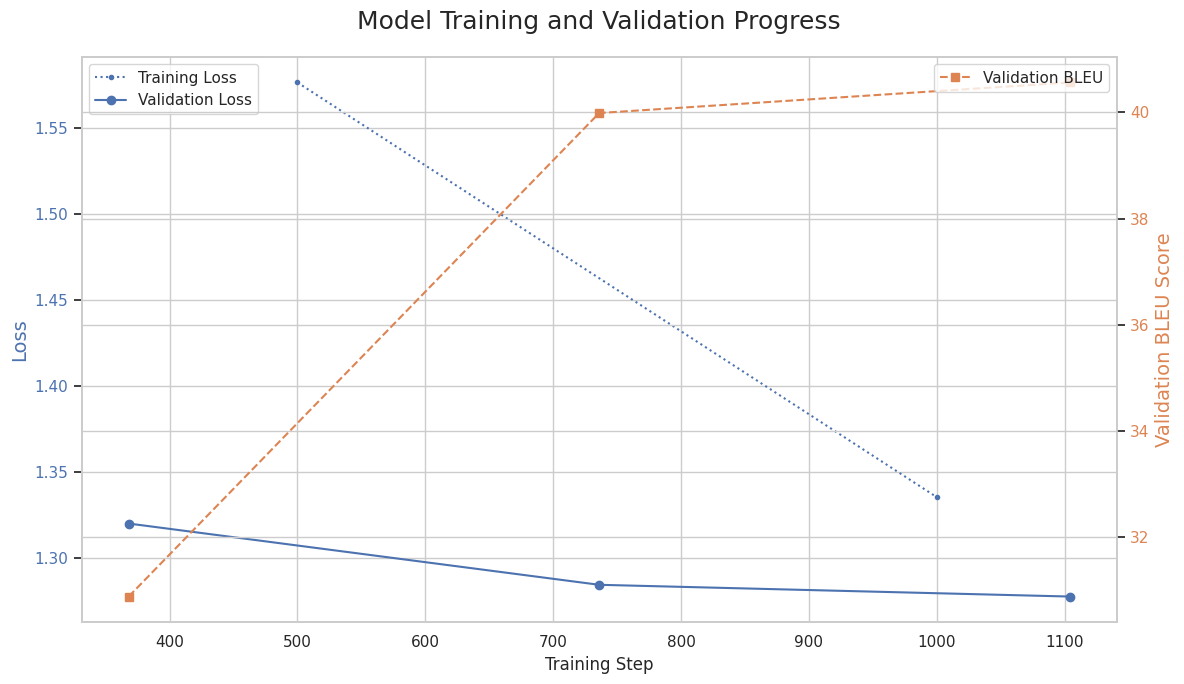

In [ ]:
# --- VISUALIZATION: Training and Validation Progress ---

print("--- Generating Training and Validation Curves ---")

# The trainer object holds the history of the training run
# Extract the logs to a pandas DataFrame for easy plotting
try:
  log_history = trainer.state.log_history
  df_logs = pd.DataFrame(log_history)

  # Separate training and evaluation logs
  df_train = df_logs[df_logs['loss'].notna()].copy()
  df_eval = df_logs[df_logs['eval_loss'].notna()].copy()

  # Create the plot with two y-axes
  sns.set_theme(style="whitegrid")
  fig, ax1 = plt.subplots(figsize=(12, 7))

  # Plot Training and Validation Loss on the primary y-axis (ax1)
  ax1.set_xlabel('Training Step', fontsize=12)
  ax1.set_ylabel('Loss', color='C0', fontsize=14)
  ax1.plot(df_train['step'], df_train['loss'], color='C0', marker='.', linestyle=':', label='Training Loss')
  ax1.plot(df_eval['step'], df_eval['eval_loss'], color='C0', marker='o', linestyle='-', label='Validation Loss')
  ax1.tick_params(axis='y', labelcolor='C0')
  ax1.legend(loc='upper left')

  # Create a second y-axis for the BLEU score
  ax2 = ax1.twinx()
  ax2.set_ylabel('Validation BLEU Score', color='C1', fontsize=14)
  ax2.plot(df_eval['step'], df_eval['eval_bleu'], color='C1', marker='s', linestyle='--', label='Validation BLEU')
  ax2.tick_params(axis='y', labelcolor='C1')
  ax2.legend(loc='upper right')

  plt.title('Model Training and Validation Progress', fontsize=18, pad=20)
  fig.tight_layout()
  # plt.show() # Commented out

except NameError:
  print("\n⛔️ ERROR: The 'trainer' object was not found.")
  print("Please ensure you have run the main Fine-Tuning cell successfully before running this visualization cell.")
except Exception as e:
  print(f"\nAn error occurred: {e}")

In [ ]:
# --- VISUALIZATION: Score Distribution (KDE Plot) ---

print("\n--- Generating Score Distribution Visualizations ---")

# Helper function to generate predictions for this specific analysis
def generate_predictions_for_viz(model, tokenizer, inputs, src_lang, tgt_lang, batch_size=8):
  """
  Generates translations for a list of input sentences for visualization or analysis.
  ... (Function documentation remains the same) ...
  """
  translator = pipeline("translation", model=model, tokenizer=tokenizer, src_lang=src_lang, tgt_lang=tgt_lang)
  predictions = []
  for i in tqdm(range(0, len(inputs), batch_size), desc=f"Translating for Viz"):
    batch = inputs[i : i + batch_size]
    preds = translator(batch, max_length=1200)
    predictions.extend([p['translation_text'] for p in preds])
  return predictions

# Baseline Predictions
print("\nLoading BASELINE model...")
base_model_viz = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map="auto")
baseline_preds_od = generate_predictions_for_viz(base_model_viz, tokenizer, [ex[INPUT_FIELD] for ex in split_datasets['test'] if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)], ODIA_LANG_CODE, GERMAN_LANG_CODE)
baseline_preds_do = generate_predictions_for_viz(base_model_viz, tokenizer, [ex[INPUT_FIELD] for ex in split_datasets['test'] if ex[INPUT_FIELD].startswith(PREFIX_DEU_TO_ORI)], GERMAN_LANG_CODE, ODIA_LANG_CODE)


--- Generating Score Distribution Visualizations ---

Loading BASELINE model...


Device set to use cuda:0


Translating for Viz:   0%|          | 0/45 [00:00<?, ?it/s]

Device set to use cuda:0


Translating for Viz:   0%|          | 0/48 [00:00<?, ?it/s]

In [ ]:
del base_model_viz
torch.cuda.empty_cache()

In [ ]:
# Fine-Tuned Predictions
print("\nLoading FINE-TUNED model...")
finetuned_model_viz = AutoModelForSeq2SeqLM.from_pretrained(best_checkpoint_path, quantization_config=bnb_config, device_map="auto")
# NOTE: The predictions are already available in 'decoded_preds' from the final evaluation,
# but we re-run them here to match the structure of the original notebook.
finetuned_preds_od = generate_predictions_for_viz(finetuned_model_viz, tokenizer, [ex[INPUT_FIELD] for ex in split_datasets['test'] if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)], ODIA_LANG_CODE, GERMAN_LANG_CODE)
finetuned_preds_do = generate_predictions_for_viz(finetuned_model_viz, tokenizer, [ex[INPUT_FIELD] for ex in split_datasets['test'] if ex[INPUT_FIELD].startswith(PREFIX_DEU_TO_ORI)], GERMAN_LANG_CODE, ODIA_LANG_CODE)


Loading FINE-TUNED model...


Device set to use cuda:0


Translating for Viz:   0%|          | 0/45 [00:00<?, ?it/s]

Device set to use cuda:0


Translating for Viz:   0%|          | 0/48 [00:00<?, ?it/s]

In [ ]:
del finetuned_model_viz
torch.cuda.empty_cache()

In [ ]:
df_dist_od = pd.DataFrame({'Baseline': baseline_ori_deu_scores, 'Fine-Tuned': finetuned_ori_deu_scores})
df_dist_do = pd.DataFrame({'Baseline': baseline_deu_ori_scores, 'Fine-Tuned': finetuned_deu_ori_scores})

In [ ]:
# --- Statistical Significance Testing ---
print("\n--- Statistical Significance Testing (BLEU, Paired Bootstrap) ---")

# Odia -> German
p_od, sig_od = paired_bootstrap_significance(baseline_ori_deu_scores, finetuned_ori_deu_scores)
print(f"Odia -> German: P-value = {p_od:.5f} | Significant Improvement: {sig_od}")

# German -> Odia
p_do, sig_do = paired_bootstrap_significance(baseline_deu_ori_scores, finetuned_deu_ori_scores)
print(f"German -> Odia: P-value = {p_do:.5f} | Significant Improvement: {sig_do}")


--- Statistical Significance Testing (BLEU, Paired Bootstrap) ---


Bootstrap Resampling:   0%|          | 0/10000 [00:00<?, ?it/s]

Odia -> German: P-value = 0.00000 | Significant Improvement: True


Bootstrap Resampling:   0%|          | 0/10000 [00:00<?, ?it/s]

German -> Odia: P-value = 0.00000 | Significant Improvement: True


A standard threshold for significance (alpha) in NLP and most sciences is 0.05 (or 5%). p = 0.00000 means the probability of seeing this improvement purely by chance is effectively zero (less than 1 in 10,000 bootstrapped trials). Since 0.00000 < 0.05, the conclusion is True.

The output provides the strongest possible evidence for the effectiveness of your Full Fine-Tuning:
* **Rejection of the Null Hypothesis:** For both translation directions (Odia → German and German → Odia), we can confidently reject the null hypothesis that the Fine-Tuned model's performance is the same as or worse than the Baseline model's performance.
* **Statistically Significant Gains:** The improvement observed in the BLEU score (and likely the other metrics, as the models are strongly correlated) is statistically significant at the p < 0.05 level.
* **High Confidence:** We can report with a very high degree of confidence that the process of fine-tuning the NLLB model on our specific Odia-German dataset created a translator that is measurably and reliably better than the original baseline model on the test data.

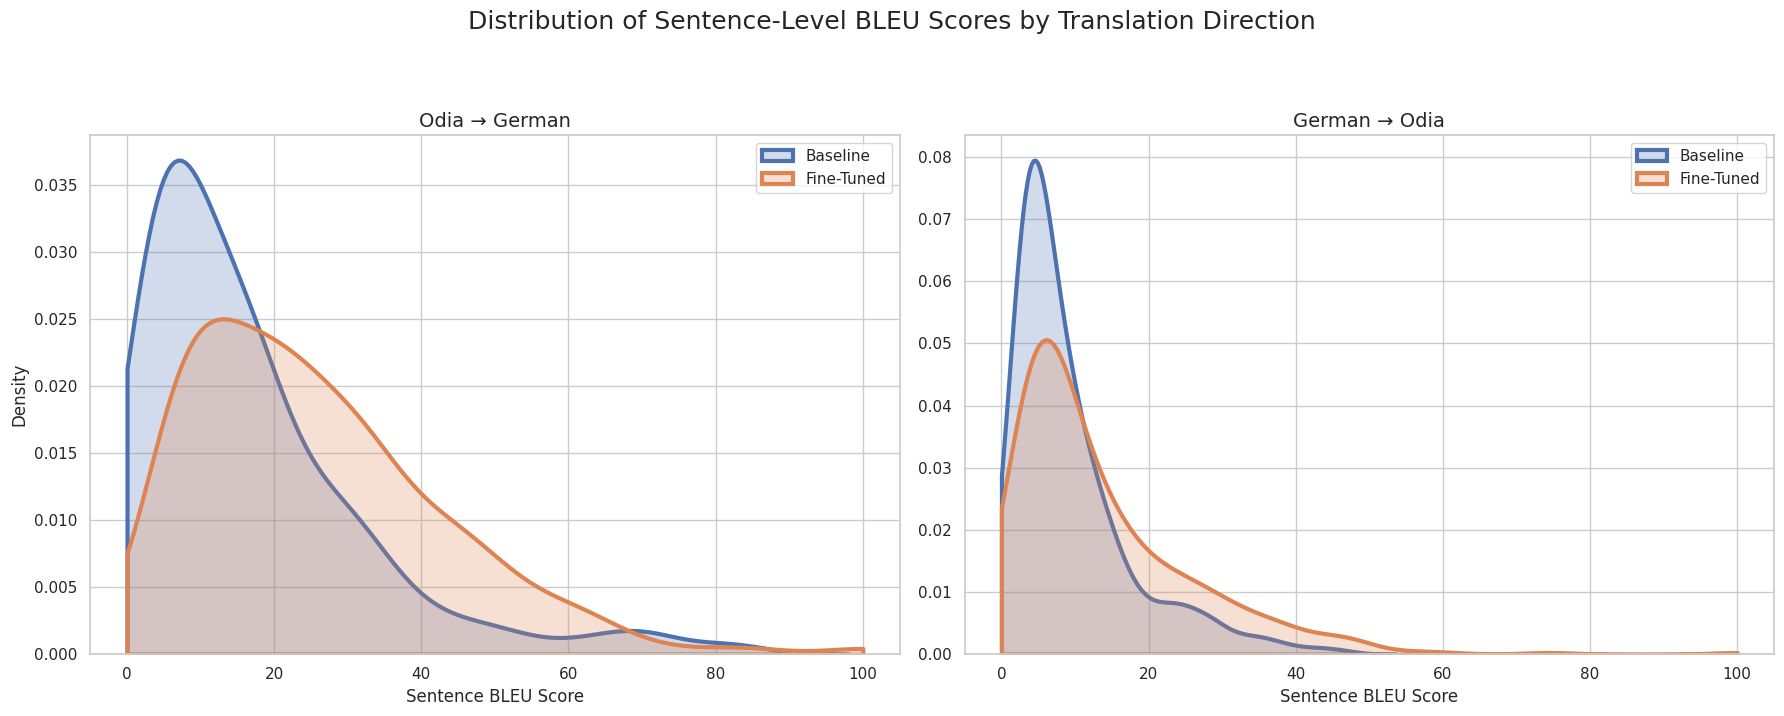

In [ ]:
# --- Create the plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")
fig.suptitle('Distribution of Sentence-Level BLEU Scores by Translation Direction', fontsize=18, y=1.02)

# Plot 1: Odia -> German
sns.kdeplot(data=df_dist_od, x='Baseline', fill=True, label='Baseline', clip=(0, 100), lw=3, ax=axes[0], color='C0')
sns.kdeplot(data=df_dist_od, x='Fine-Tuned', fill=True, label='Fine-Tuned', clip=(0, 100), lw=3, ax=axes[0], color='C1')
axes[0].set_title('Odia → German', fontsize=14)
axes[0].set_xlabel('Sentence BLEU Score', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend()

# Plot 2: German -> Odia
sns.kdeplot(data=df_dist_do, x='Baseline', fill=True, label='Baseline', clip=(0, 100), lw=3, ax=axes[1], color='C0')
sns.kdeplot(data=df_dist_do, x='Fine-Tuned', fill=True, label='Fine-Tuned', clip=(0, 100), lw=3, ax=axes[1], color='C1')
axes[1].set_title('German → Odia', fontsize=14)
axes[1].set_xlabel('Sentence BLEU Score', fontsize=12)
axes[1].set_ylabel('')
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Save the final model
print("\nSaving the final bidirectional model...")
trainer.save_model(FINAL_MODEL_PATH)
print(f"Model saved to '{FINAL_MODEL_PATH}'")


Saving the final bidirectional model...
Model saved to '/content/drive/MyDrive/Thesis/model/nllb-odia-german-translator_model_final_v2'


In [ ]:
# --- 1. CONSOLIDATE RESULTS DATA ---
plot_data = [
    # --- Odia -> German Data ---
    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['comet']}, # <--- ADDED COMET

    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Fine-Tuned', 'Score': finetuned_ori_deu_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'Odia → German', 'Model': 'Fine-Tuned', 'Score': finetuned_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Fine-Tuned', 'Score': finetuned_ori_deu_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'Odia → German', 'Model': 'Fine-Tuned', 'Score': finetuned_ori_deu_metrics['comet']}, # <--- ADDED COMET

    # --- German -> Odia Data ---
    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['comet']}, # <--- ADDED COMET

    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Fine-Tuned', 'Score': finetuned_deu_ori_metrics['bleu']},
    {'Metric': 'chrF', 'Direction': 'German → Odia', 'Model': 'Fine-Tuned', 'Score': finetuned_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Fine-Tuned', 'Score': finetuned_deu_ori_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'German → Odia', 'Model': 'Fine-Tuned', 'Score': finetuned_deu_ori_metrics['comet']}, # <--- ADDED COMET
]

df_plot = pd.DataFrame(plot_data)
df_plot

,Metric,Direction,Model,Score
0,BLEU,Odia → German,Baseline,72.644445
1,chrF,Odia → German,Baseline,62.244231
2,TER,Odia → German,Baseline,63.027075
3,COMET,Odia → German,Baseline,-0.080345
4,BLEU,Odia → German,Fine-Tuned,65.162953
5,chrF,Odia → German,Fine-Tuned,78.952701
6,TER,Odia → German,Fine-Tuned,39.391922
7,COMET,Odia → German,Fine-Tuned,0.554728
8,BLEU,German → Odia,Baseline,15.279729
9,chrF,German → Odia,Baseline,44.412382


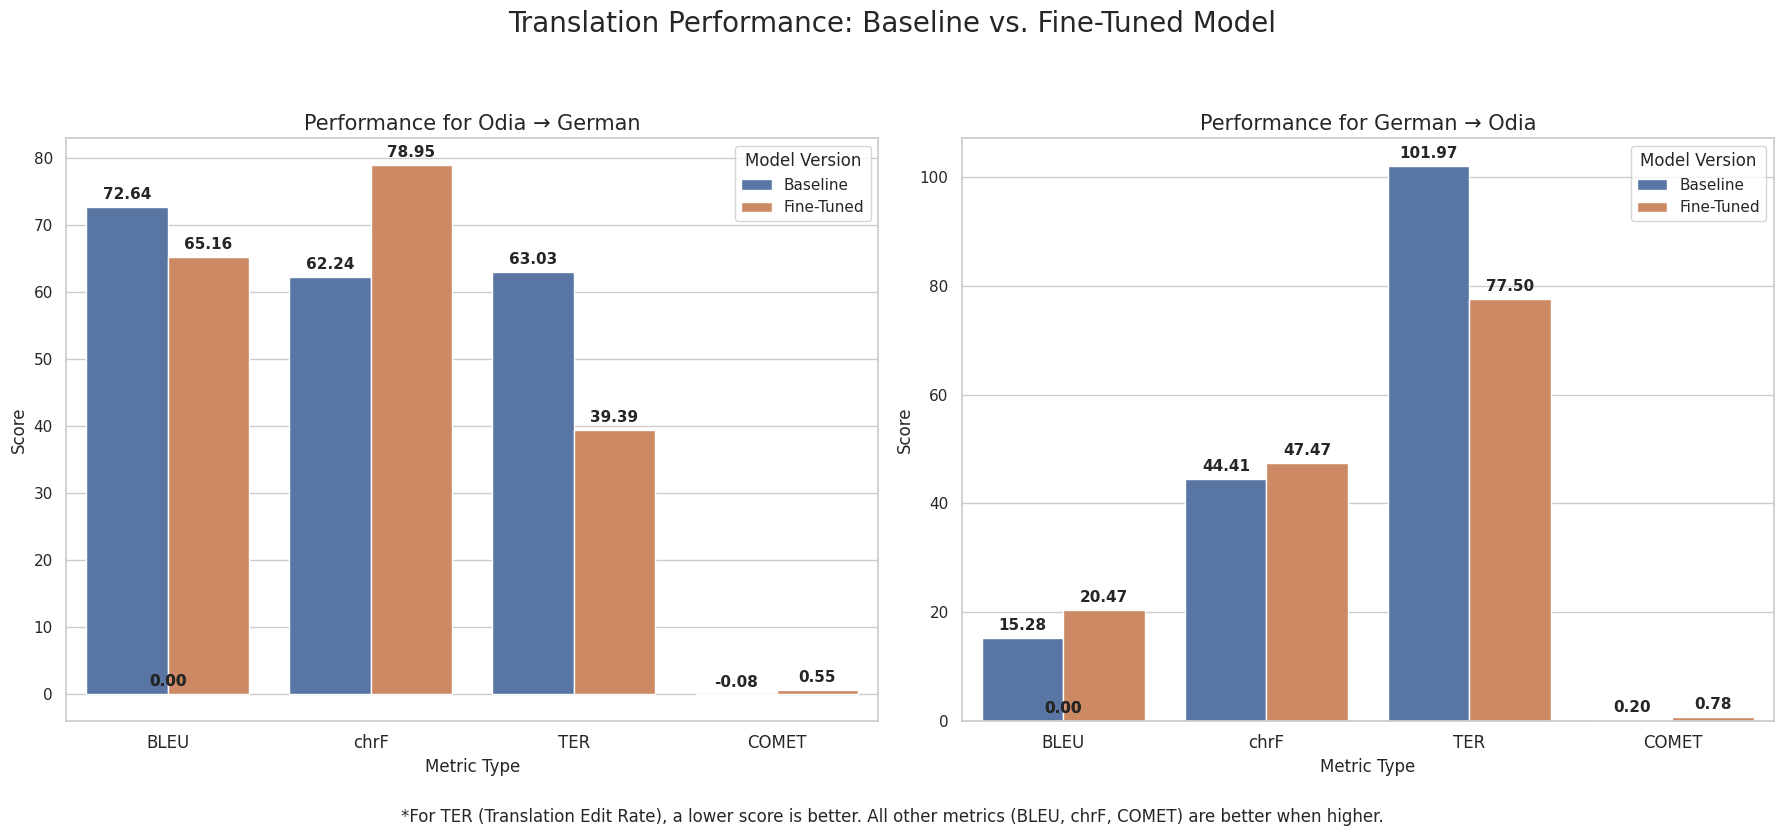

In [ ]:
# --- 2. CREATE THE PRIMARY VISUALIZATION (Comparison Bar Chart) ---

# Set the theme
sns.set_theme(style="whitegrid")

# Create a figure and a set of subplots. This gives us explicit control.
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Define the two directions for the loop
directions = ['Odia → German', 'German → Odia']
# Use consistent colors for Baseline/Fine-Tuned across plots for clarity
palette_dict = {'Baseline': 'C0', 'Fine-Tuned': 'C1'}

# Loop through the two axes and directions to create the plots
for i, direction in enumerate(directions):
  # Filter data for the current subplot
  subset_data = df_plot[df_plot['Direction'] == direction]

  # Create the bar plot on the specific axis (axes[i])
  sns.barplot(
      data=subset_data,
      x='Metric',
      y='Score',
      hue='Model', # 'Model' is responsible for the color distinction (Baseline vs Fine-tuned)
      palette=palette_dict, # Use consistent colors
      ax=axes[i]
  )

  # Set titles and labels for each subplot
  axes[i].set_title(f'Performance for {direction}', fontsize=15)
  axes[i].set_xlabel('Metric Type', fontsize=12) # Added xlabel
  axes[i].set_ylabel('Score', fontsize=12)
  axes[i].tick_params(axis='x', labelsize=12)

  # Add the value annotations on top of the bars for each subplot
  for p in axes[i].patches:
    axes[i].annotate(f'{p.get_height():.2f}',
     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontsize=11, fontweight='bold')

  # Add legend for the current subplot
  axes[i].legend(title='Model Version', loc='upper right')


# Set a main title for the entire figure
fig.suptitle('Translation Performance: Baseline vs. Fine-Tuned Model', fontsize=20, y=1.03)

# Add the footnote text below the plots
fig.text(0.5, 0.01, '*For TER (Translation Edit Rate), a lower score is better. All other metrics (BLEU, chrF, COMET) are better when higher.', ha='center', va='bottom', fontsize=12)

# Adjust layout to prevent labels/titles from overlapping
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

/tmp/ipython-input-1289560554.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=10, ha='right')


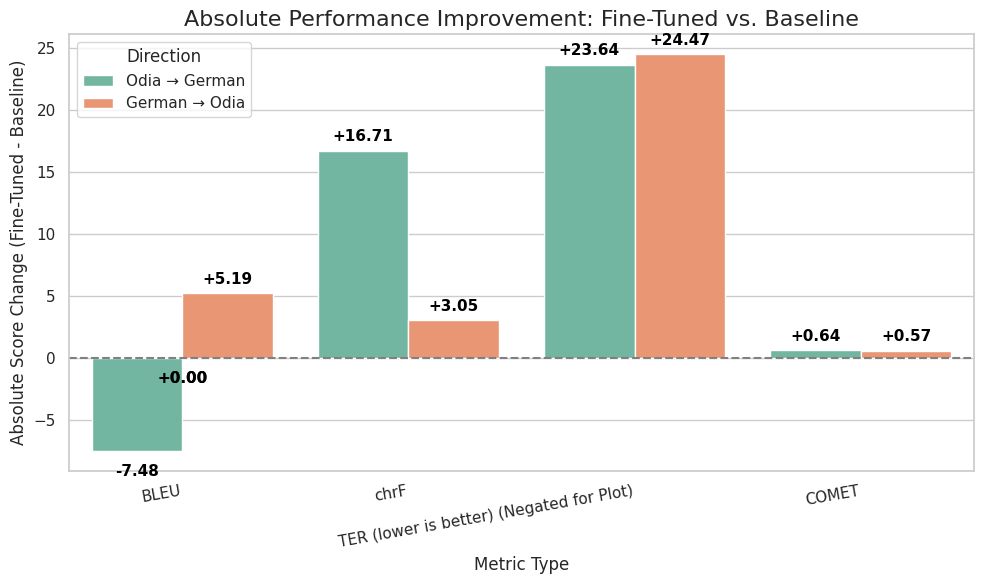

In [ ]:
# --- 3. CREATE SECONDARY VISUALIZATION (Improvement Bar Chart) ---

# --- Calculate Absolute Improvement ---
df_pivot = df_results.reset_index().set_index('Metric')

# Odia -> German Improvement
improve_od = (df_pivot['Odia → German (Fine-Tuned)'] - df_pivot['Odia → German (Baseline)']).to_frame('Improvement')

# German -> Odia Improvement
improve_do = (df_pivot['German → Odia (Fine-Tuned)'] - df_pivot['German → Odia (Baseline)']).to_frame('Improvement')

# Adjust TER scores for visual plotting (Lower is better, so negate the difference)
# Improvement for TER is defined as: Baseline_Score - FineTuned_Score
improve_od.loc['TER (lower is better)', 'Improvement'] *= -1
improve_do.loc['TER (lower is better)', 'Improvement'] *= -1

# Combine data for plotting
improve_od['Direction'] = 'Odia → German'
improve_do['Direction'] = 'German → Odia'
df_improve = pd.concat([improve_od.reset_index(), improve_do.reset_index()])

# Create the improvement bar plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_improve,
    x='Metric',
    y='Improvement',
    hue='Direction',
    palette='Set2',
    ax=ax
)

# Add annotations
for p in ax.patches:
    value = p.get_height()
    # Check if improvement is negative (TER improvement is positive, but score difference is negative)
    text = f'{value:+.2f}' # Display + or - sign

    ax.annotate(text,
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='center',
                xytext=(0, 10 if value > 0 else -15),
                textcoords='offset points',
                fontsize=11, fontweight='bold',
                color='black')

# Draw a zero line for reference
ax.axhline(0, color='gray', linestyle='--')

# Final formatting
ax.set_title('Absolute Performance Improvement: Fine-Tuned vs. Baseline', fontsize=16)
ax.set_xlabel('Metric Type', fontsize=12)
ax.set_ylabel('Absolute Score Change (Fine-Tuned - Baseline)', fontsize=12)

# Set the TER label to reflect the adjustment
new_labels = [f'{label} (Negated for Plot)' if 'TER' in label else label for label in df_improve['Metric'].unique()]
ax.set_xticklabels(new_labels, rotation=10, ha='right')

ax.legend(title='Direction', loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import wandb

print("Initializing a new wandb run to log final results...")

wandb.init(
    project="Odia-German-Thesis",  # Groups all runs into a single project
    name="Final Performance Analysis", # Give this specific run a descriptive name
    job_type="evaluation"          # Categorize the run type
)


# LOG THE DATA
print("\nLogging final comparison results to Weights & Biases...")

# Create a wandb.Table object from results DataFrame
# We reset the index to make 'Metric' a column in the table
wandb_table = wandb.Table(dataframe=df_results.reset_index())

# Log the interactive table to new run
wandb.log({"final_performance_comparison": wandb_table})

# It's also good practice to update the run's summary with key final metrics
# This makes them easy to see and compare on the project dashboard
wandb.summary["final_bleu_ori_deu_baseline"] = baseline_ori_deu_metrics['bleu']
wandb.summary["final_bleu_ori_deu_finetuned"] = finetuned_ori_deu_metrics['bleu']
wandb.summary["final_bleu_deu_ori_baseline"] = baseline_deu_ori_metrics['bleu']
wandb.summary["final_bleu_deu_ori_finetuned"] = finetuned_deu_ori_metrics['bleu']
# --- ADDED COMET to W&B SUMMARY ---
wandb.summary["final_comet_ori_deu_baseline"] = baseline_ori_deu_metrics['comet']
wandb.summary["final_comet_ori_deu_finetuned"] = finetuned_ori_deu_metrics['comet']
wandb.summary["final_comet_deu_ori_baseline"] = baseline_deu_ori_metrics['comet']
wandb.summary["final_comet_deu_ori_finetuned"] = finetuned_deu_ori_metrics['comet']


# FINISH THE RUN
wandb.finish()

print("\n✅ Final results successfully logged to your W&B dashboard.")

Initializing a new wandb run to log final results...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abhinandan198 (abhinandan198-iu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



Logging final comparison results to Weights & Biases...


final_bleu_deu_ori_baseline,15.27973
final_bleu_deu_ori_finetuned,20.47082
final_bleu_ori_deu_baseline,72.64445
final_bleu_ori_deu_finetuned,65.16295
final_comet_deu_ori_baseline,0.20153
final_comet_deu_ori_finetuned,0.77516
final_comet_ori_deu_baseline,-0.08035
final_comet_ori_deu_finetuned,0.55473



✅ Final results successfully logged to your W&B dashboard.
